# testing and trying to deploy a deep learning model for genre classification based on the book covers

In [1]:
import pandas as pd

df = pd.read_parquet('../../data/ml_features_dl/part-00000-08e073d0-1da8-4ea5-b369-f48da99acdc7-c000.snappy.parquet')
df

,id,genre_vector
0,91201.Doctors,"[1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, ..."
1,39216527-paradise-rot,"[1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,21481566-the-inheritance-trilogy,"[1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,23249706-etta-and-otto-and-russell-and-james,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, ..."
4,24357334-forever-with-you,"[1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...
25797,231869.SeinLanguage,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
25798,40669887-cheaper-by-the-dozen,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
25799,7981456-a-long-walk-to-water,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, ..."
25800,34715224-flight-of-magpies,"[0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, ..."


In [2]:
import pandas as pd

mapping = pd.read_parquet('../../data/genre_vector_mapping/part-00000-d3e4b1e5-cb1f-4ceb-9884-550580960b4e-c000.snappy.parquet')
mapping

,index,genre
0,0,Fiction
1,1,Audiobook
2,2,Romance
3,3,Fantasy
4,4,Adult
5,5,Contemporary
6,6,Mystery
7,7,Young Adult
8,8,Thriller
9,9,Historical Fiction


In [3]:
from pathlib import Path

image_dir = Path("../../images")

df = df.copy()

df["image_path"] = df["id"].apply(lambda x: image_dir / f"{x}.jpg")

df_subset = df[df["image_path"].apply(lambda p: p.exists())].reset_index(drop=True)
df_subset

,id,genre_vector,image_path
0,91201.Doctors,"[1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, ...",..\..\images\91201.Doctors.jpg
1,23249706-etta-and-otto-and-russell-and-james,"[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, ...",..\..\images\23249706-etta-and-otto-and-russel...
2,24357334-forever-with-you,"[1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...",..\..\images\24357334-forever-with-you.jpg
3,19186402-private-india,"[1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, ...",..\..\images\19186402-private-india.jpg
4,682751.Animalia,"[1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...",..\..\images\682751.Animalia.jpg
...,...,...,...
10870,27213168-i-contain-multitudes,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...",..\..\images\27213168-i-contain-multitudes.jpg
10871,31299.Hickory_Dickory_Dock,"[1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, ...",..\..\images\31299.Hickory_Dickory_Dock.jpg
10872,283494.Ironside,"[1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...",..\..\images\283494.Ironside.jpg
10873,7981456-a-long-walk-to-water,"[1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, ...",..\..\images\7981456-a-long-walk-to-water.jpg


In [4]:
from sklearn.model_selection import train_test_split

In [5]:
train_df, temp_df = train_test_split(
    df_subset,
    test_size=0.2,
    random_state=42,
    shuffle=True
)


val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

In [6]:
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset

In [ ]:
class BookDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

        self.labels = torch.tensor(
            np.stack(df["genre_vector"].values),
            dtype=torch.float32
        )

        self.image_paths = df["image_path"].values

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        label = self.labels[idx]

        return img, label

In [8]:
from torchvision import transforms

In [9]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [10]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [11]:
train_dataset = BookDataset(train_df, transform=train_transform)
val_dataset   = BookDataset(val_df, transform=val_transform)
test_dataset  = BookDataset(test_df, transform=val_transform)

In [12]:
from torch.utils.data import DataLoader

In [13]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0)

# the actual model step

In [14]:
import torch
import torch.nn as nn
from torchvision import models

In [15]:
model = models.efficientnet_b0(weights="IMAGENET1K_V1")

In [16]:
num_genres = len(mapping)
num_genres

29

In [17]:
in_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(in_features, num_genres)

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [19]:
criterion = nn.BCEWithLogitsLoss()

In [20]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

In [21]:
print(train_df["image_path"].iloc[0])
from PIL import Image
Image.open(train_df["image_path"].iloc[0]).show()

..\..\images\1228958.Au_bonheur_des_ogres.jpg


In [22]:
print("Dataset size:", len(train_loader.dataset))

Dataset size: 8700


In [23]:
images, labels = next(iter(train_loader))
print("Batch loaded OK")

Batch loaded OK


In [24]:
num_epochs=60

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    print("epoch start")

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        #print(train_loss)

    print(f"Epoch {epoch}, Loss: {train_loss / len(train_loader)}")

epoch start
Epoch 0, Loss: 0.41271011104040284
epoch start
Epoch 1, Loss: 0.3645467705997255
epoch start
Epoch 2, Loss: 0.34508866944131167
epoch start
Epoch 3, Loss: 0.328132612617029
epoch start
Epoch 4, Loss: 0.3144423530491836
epoch start
Epoch 5, Loss: 0.30057701708146317
epoch start
Epoch 6, Loss: 0.28482394927071736
epoch start
Epoch 7, Loss: 0.2709607066559222
epoch start
Epoch 8, Loss: 0.26205409399014623
epoch start
Epoch 9, Loss: 0.2531597084256218
epoch start
Epoch 10, Loss: 0.2399606130852857
epoch start
Epoch 11, Loss: 0.23135783965699375
epoch start
Epoch 12, Loss: 0.2215914310860064
epoch start
Epoch 13, Loss: 0.2175838764729526
epoch start
Epoch 14, Loss: 0.2086246669265058
epoch start
Epoch 15, Loss: 0.20126959217904025
epoch start
Epoch 16, Loss: 0.19545987616156174
epoch start


KeyboardInterrupt: 

In [27]:
torch.save({
    "epoch": epoch,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
}, "../../models/latest_checkpoint.pth")

In [ ]:
torch.save(model.state_dict(), "../../models/model_3.pth")

In [28]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs)

        all_preds.append(probs.cpu())
        all_labels.append(labels.cpu())

In [29]:
from sklearn.metrics import f1_score
import numpy as np
import torch

In [30]:
def evaluate(model, loader, device, threshold=0.5):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs)

            preds = (probs > threshold).int()

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu().int())

    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_labels).numpy()

    micro = f1_score(y_true, y_pred, average="micro", zero_division=0)
    macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

    return micro, macro

In [31]:
val_micro, val_macro = evaluate(model, val_loader, device)

print(f"Val Micro F1: {val_micro:.4f}")
print(f"Val Macro F1: {val_macro:.4f}")

Val Micro F1: 0.5618
Val Macro F1: 0.4851


In [32]:
test_micro, test_macro = evaluate(model, test_loader, device)

print("TEST RESULTS")
print(f"Micro F1: {test_micro:.4f}")
print(f"Macro F1: {test_macro:.4f}")

TEST RESULTS
Micro F1: 0.5667
Macro F1: 0.4930


In [33]:
import torch
import numpy as np
import cv2
from torchvision import transforms
from PIL import Image

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [34]:
target_layer = model.features[-1]

In [35]:
cam = GradCAM(
    model=model,
    target_layers=[target_layer]
)

In [36]:
def load_image(path):
    img = Image.open(path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])

    tensor = transform(img).unsqueeze(0)
    return img.resize((224,224)), tensor

In [37]:
def get_cam(image_tensor):
    image_tensor = image_tensor.to(device)

    outputs = model(image_tensor)
    probs = torch.sigmoid(outputs)

    top_class = torch.argmax(probs, dim=1).item()

    grayscale_cam = cam(
        input_tensor=image_tensor,
        targets=[ClassifierOutputTarget(top_class)]
    )[0]

    return grayscale_cam, probs

In [38]:
def visualize_cam(img_pil, cam_map):
    img = np.array(img_pil).astype(np.float32) / 255.0

    visualization = show_cam_on_image(img, cam_map, use_rgb=True)

    return visualization

In [39]:
def explain_image(path):
    img_pil, tensor = load_image(path)

    cam_map, probs = get_cam(tensor)

    result = visualize_cam(img_pil, cam_map)

    return result, probs

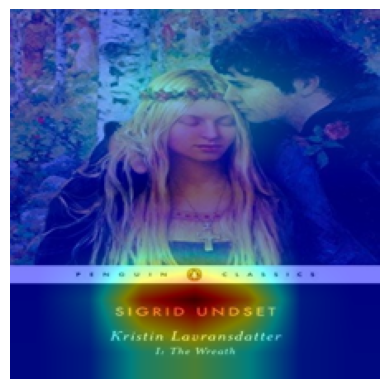

In [40]:
import matplotlib.pyplot as plt

img, probs = explain_image("../../images/6220.The_Wreath.jpg")

plt.imshow(img)
plt.axis("off")
plt.show()

In [41]:
model = models.efficientnet_b0(weights=None)

in_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    in_features,
    29
)

model.load_state_dict(
    torch.load("../../models/model_2.pth")
)

model = model.to(device)
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [42]:
def extract_embeddings(model, images):

    x = model.features(images)

    x = model.avgpool(x)

    x = torch.flatten(x, 1)

    return x

In [43]:
images, labels = next(iter(test_loader))

images = images.to(device)

embeddings = extract_embeddings(
    model,
    images
)

print(embeddings.shape)

torch.Size([8, 1280])


In [44]:
torch.Size([8, 1280])

torch.Size([8, 1280])

In [45]:
genre_names = mapping["genre"].tolist()

In [46]:
split_map = {}

for book_id in train_df["id"]:
    split_map[book_id] = "train"

for book_id in val_df["id"]:
    split_map[book_id] = "val"

for book_id in test_df["id"]:
    split_map[book_id] = "test"

In [47]:
rows = []

model.eval()

with torch.no_grad():

    for _, row in df_subset.iterrows():

        img = Image.open(row["image_path"]).convert("RGB")

        tensor = val_transform(img)
        tensor = tensor.unsqueeze(0).to(device)

        logits = model(tensor)

        probs = torch.sigmoid(logits)

        preds = (probs > 0.5).int()

        embedding = extract_embeddings(
            model,
            tensor
        )[0]

        record = {
            "id": row["id"],
            "split": split_map[row["id"]],

            "embedding": embedding.cpu().tolist(),

            "true_labels": row["genre_vector"],
            "pred_labels": preds[0].cpu().tolist(),
            "pred_probs": probs[0].cpu().tolist()
        }

        for i, genre in enumerate(genre_names):

            record[f"{genre}_true"] = int(
                row["genre_vector"][i]
            )

            record[f"{genre}_pred"] = int(
                preds[0][i]
            )

            record[f"{genre}_prob"] = float(
                probs[0][i]
            )

        rows.append(record)

In [48]:
analysis_df = pd.DataFrame(rows)

In [49]:
analysis_df

,id,split,embedding,true_labels,pred_labels,pred_probs,Fiction_true,Fiction_pred,Fiction_prob,Audiobook_true,...,Adult Fiction_prob,Magic_true,Magic_pred,Magic_prob,Science Fiction Fantasy_true,Science Fiction Fantasy_pred,Science Fiction Fantasy_prob,Urban Fantasy_true,Urban Fantasy_pred,Urban Fantasy_prob
0,91201.Doctors,val,"[0.681947648525238, -0.05318159982562065, -0.1...","[1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, ...","[1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, ...","[0.9964718818664551, 0.10974834859371185, 0.26...",1,1,0.996472,0,...,1.376906e-02,0,0,0.009284,0,0,0.010180,0,0,2.183867e-04
1,23249706-etta-and-otto-and-russell-and-james,train,"[0.4454370439052582, -0.1367894411087036, 1.14...","[1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[0.039440568536520004, 0.06355588138103485, 0....",1,0,0.039441,0,...,5.928586e-07,0,0,0.000066,0,0,0.000028,0,0,9.661118e-05
2,24357334-forever-with-you,train,"[0.47720298171043396, -0.1317540854215622, -0....","[1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...","[0.8144105076789856, 0.2330247014760971, 0.993...",1,1,0.814411,0,...,3.789367e-03,0,0,0.001538,0,0,0.000083,0,0,7.194768e-04
3,19186402-private-india,test,"[0.7176530361175537, -0.08156656473875046, -0....","[1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, ...","[1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, ...","[0.9999046325683594, 0.9810782074928284, 0.000...",1,1,0.999905,1,...,3.532131e-03,0,0,0.020324,0,0,0.479707,0,0,2.678392e-03
4,682751.Animalia,train,"[-0.21237412095069885, -0.15298710763454437, 0...","[1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...","[1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ...","[0.9999946355819702, 0.0006722531979903579, 0....",1,1,0.999995,0,...,1.854775e-05,0,0,0.005539,0,0,0.000076,0,0,4.960816e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10870,27213168-i-contain-multitudes,train,"[0.4617546796798706, -0.11614221334457397, 0.8...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, ...","[0.1272958368062973, 0.4340977072715759, 0.001...",0,0,0.127296,1,...,1.082906e-05,0,0,0.000057,0,0,0.001277,0,0,5.571911e-05
10871,31299.Hickory_Dickory_Dock,train,"[0.11238083988428116, -0.11132387071847916, 0....","[1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, ...","[1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0.809033215045929, 0.22946128249168396, 0.713...",1,1,0.809033,1,...,3.735999e-03,0,0,0.003717,0,0,0.000057,0,0,2.178985e-02
10872,283494.Ironside,train,"[0.6307184100151062, -0.1659257411956787, -0.0...","[1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...","[0.7153726816177368, 0.05363284796476364, 0.06...",1,1,0.715373,0,...,8.716991e-07,1,0,0.033490,0,0,0.001643,1,0,1.635883e-01
10873,7981456-a-long-walk-to-water,val,"[0.11812001466751099, -0.08007825165987015, 0....","[1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, ...","[1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0.8137561678886414, 0.5768641233444214, 0.051...",1,1,0.813756,0,...,3.937432e-01,0,0,0.000717,0,0,0.000851,0,0,1.136877e-04


In [50]:
analysis_df.to_parquet(
    "../../data/book_cover_analysis.parquet",
    index=False
)